# Minichallenge 2 Notebook 1
Dieses Notbook enthält die Abgaben für die Tage 1 - 3 für die GBSV Minichallenge 1. Der Code sowie die Daten sind in einem GitHub Repository verfügbar und unter diesem Link zu finden: [GitHub Repository](https://github.com/adrianmeier2002/gbsv_minichallenges).

## Tag 1: Augmentationsverfahren Definieren

Ich habe für die GBSV Minichallenge Kanada als Land gewählt, da Teile meiner Familie (Onkel und Cousin) in Kanada, genauer in Montreal, leben. Ich war selber schon zwei Mal in Kanada und habe gerade Montreal als sehr schöne Stadt in Erinnerung. Ich habe für die ersten Aufgeben drei verschiedene Bilder Gewählt. Das erste Bild ist eine eigene Aufnahme von mir, die ich in Montreal gemacht habe, darauf ist die Skyline von Montreal zu sehen, jedoch war zu dieser Zeit der [grosse Waldbrand](https://de.wikipedia.org/wiki/Waldbr%C3%A4nde_in_Kanada_2023) in Kanada (2023), weshalb der Himmel sehr Rauchig ist. Das Zweite Bild stammt von der Flagge Kanadas, dies ist ein sehr bekanntes Symbol für Kanada. Das Bild stammt vom [Wikipediaartikel](https://de.wikipedia.org/wiki/Flagge_Kanadas) zur Kanadischen Flagge. Als drittes Bild habe ich ein Bild mit viel Schnee gewählt, da Kanada für seine kalten Winter bekannt ist und dies für weitere analysen interessant sein könnte. Das Bild stammt aus der [kleine Kinderzeitung](https://kinderzeitung.kleinezeitung.at/nach-wintersturm-in-eis-und-schnee-gepackt/.)

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

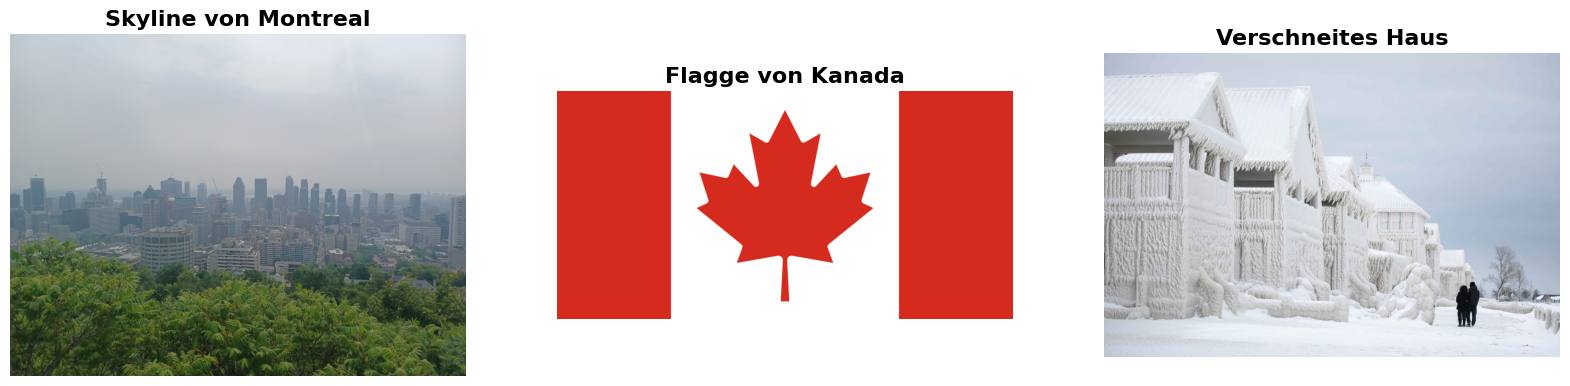

In [44]:
# Laden der Bilder
skyline = cv2.imread('Images/skyline.jpg')
flag = cv2.imread('Images/flag.jpg')
snow_house = cv2.imread('Images/snow_house.jpg')

# Ausgeben der Bilder
images = [skyline, flag, snow_house]
titles = ['Skyline von Montreal', 'Flagge von Kanada', 'Verschneites Haus']
plt.figure(figsize=(20,10))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i], fontsize=16, fontweight='bold')
    plt.axis('off')
plt.show()



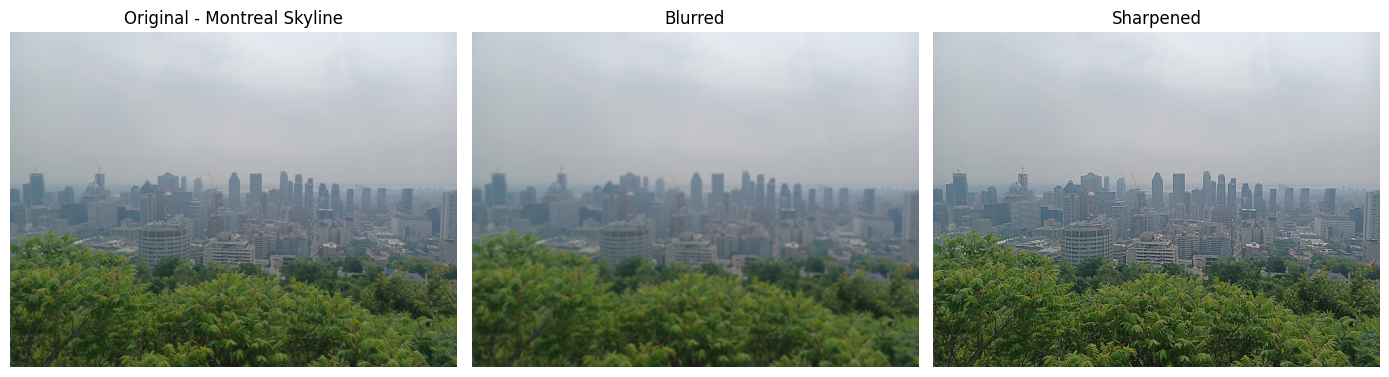

In [45]:
# Hilfsfunktion für Darstellung
def show(imgs, titles, cmap='gray'):
    plt.figure(figsize=(14,4))
    for i, (im, t) in enumerate(zip(imgs, titles)):
        plt.subplot(1, len(imgs), i+1)
        if len(im.shape) == 2:
            plt.imshow(im, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Gaussian Blur auf das Skyline Bild anwenden
blurred = cv2.GaussianBlur(skyline, (9, 9), 10)

sharpened = cv2.addWeighted(skyline, 2, blurred, -1, 0)

show([skyline, blurred, sharpened], ['Original - Montreal Skyline', 'Blurred', 'Sharpened'])

    

Hier wurde das Augmentationsverfahren zur Schärfung des Skyline Bildes angewendet.

Für die Schärfung des Skyline Bildes habe ich zuerst ein Gaussian Blur angewendet, dieser ersetzt jedes Pixel durch den gewichteten Durchschnitt seiner Nachbarpixel, wodurch das Bild unschärfer wird. Anschliessend habe ich das ursprüngliche Bild mit dem unscharfen Bild kombiniert, indem ich das unscharfe Bild mit einem negativen Gewicht multipliziert und zum ursprünglichen Bild addiert habe. Dies hebt die Kanten im Bild hervor und erzeugt einen Schärfungseffekt. Die Parameter habe ich experimentell gewählt, wenn das Verhältnis nicht stimmt, sieht das Bild schnell unnatürlich oder zu dunkel aus.

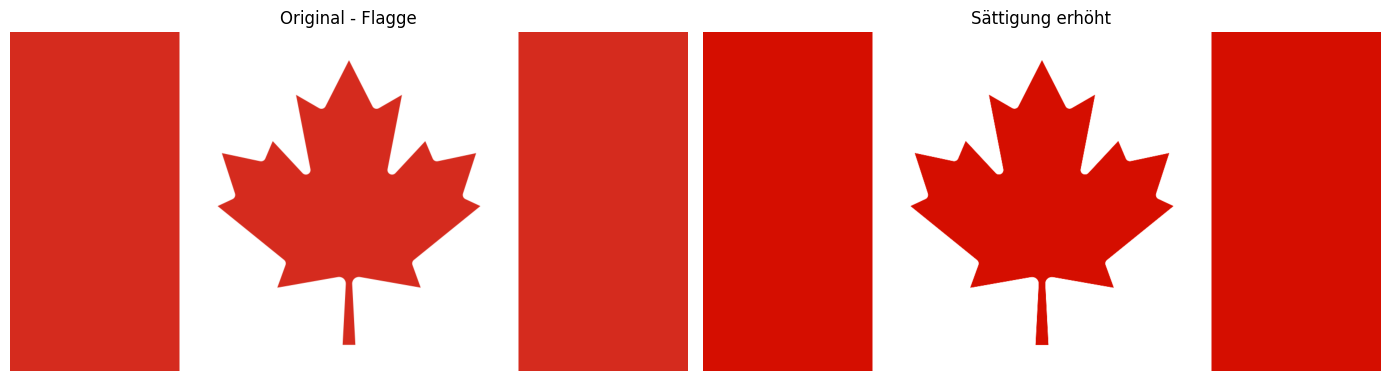

In [46]:
hsv = cv2.cvtColor(flag, cv2.COLOR_BGR2HSV).astype("float32")
hsv[...,1] *= 2 # Sättigung erhöhen
hsv[...,1] = np.clip(hsv[...,1], 0, 255)
img_flag_boost = cv2.cvtColor(hsv.astype("uint8"), cv2.COLOR_HSV2BGR)

show([flag, img_flag_boost], ['Original - Flagge', 'Sättigung erhöht'])

Hier wurde das Augmentationsverfahren zur Erhöhung der Sättigung des Flaggen Bildes angewendet.

Dabei wurde das Bild zuerst von RGB in den HSV Farbraum konvertiert. Anschliessend wurde der Sättigungswert (S) jedes Pixels um den Faktor 2 erhöht, wobei darauf geachtet wurde, dass der Wert 255 nicht überschritten wird. Danach wurde das Bild zurück in den RGB Farbraum konvertiert, um das Ergebnis zu erhalten. Dies führt zu lebendigeren Farben im Bild.

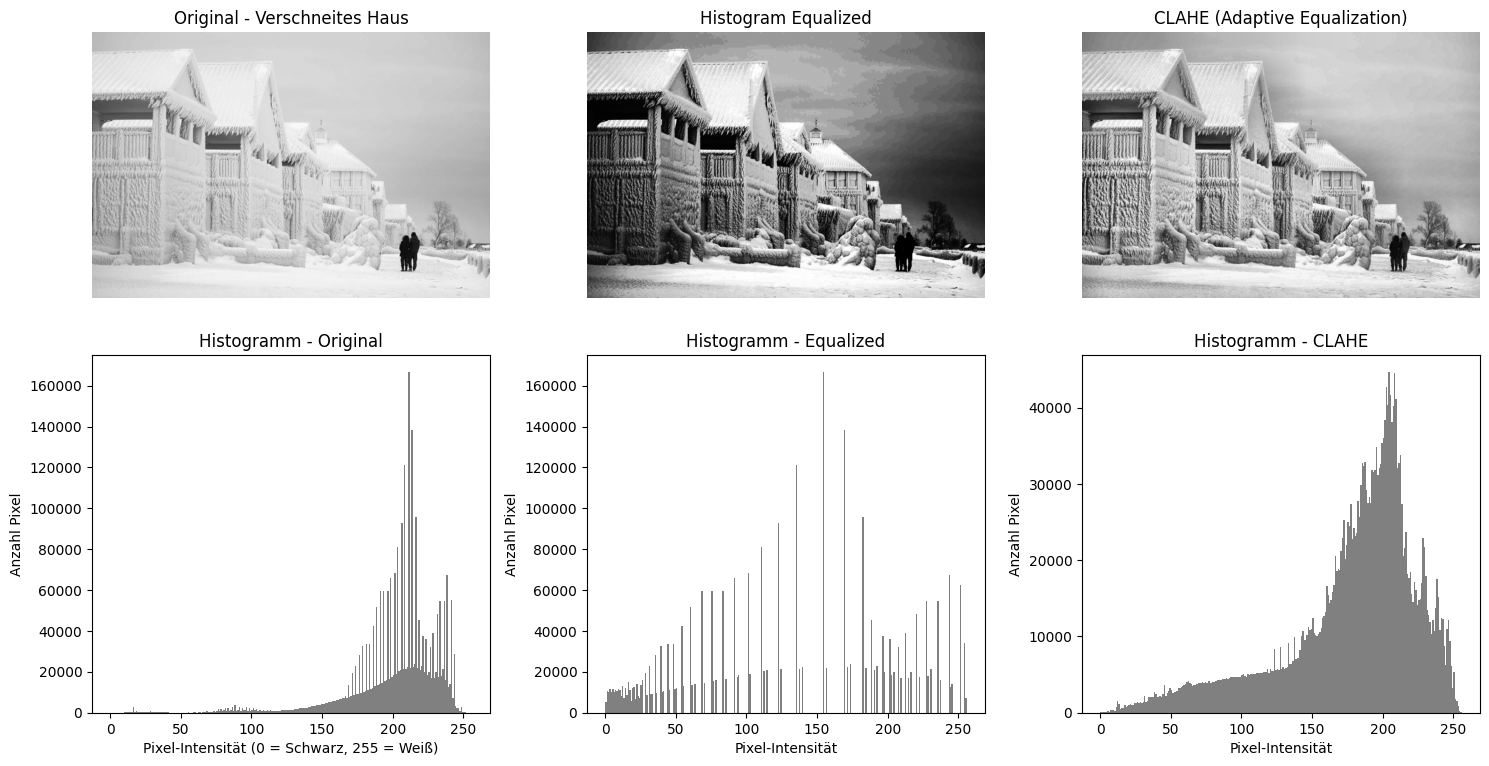

In [47]:
# --- Lade Graustufenbild ---
snow_house_grey = cv2.imread('Images/snow_house.jpg', cv2.IMREAD_GRAYSCALE)
if snow_house_grey is None:
    raise FileNotFoundError("Fehler: 'Images/snow_house.jpg' nicht gefunden!")

# --- Normale Histogramm Equalization ---
house_equalized = cv2.equalizeHist(snow_house_grey)

# --- CLAHE (lokale Anpassung) ---
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
house_clahe = clahe.apply(snow_house_grey)

# --- Darstellung der Bilder & Histogramme ---
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# --- Originalbild ---
axs[0,0].imshow(snow_house_grey, cmap='gray')
axs[0,0].set_title('Original - Verschneites Haus')
axs[0,0].axis('off')

axs[1,0].hist(snow_house_grey.ravel(), bins=256, range=(0, 256), color='gray')
axs[1,0].set_title('Histogramm - Original')
axs[1,0].set_xlabel('Pixel-Intensität (0 = Schwarz, 255 = Weiß)')
axs[1,0].set_ylabel('Anzahl Pixel')

# --- Histogramm Equalization ---
axs[0,1].imshow(house_equalized, cmap='gray')
axs[0,1].set_title('Histogram Equalized')
axs[0,1].axis('off')

axs[1,1].hist(house_equalized.ravel(), bins=256, range=(0, 256), color='gray')
axs[1,1].set_title('Histogramm - Equalized')
axs[1,1].set_xlabel('Pixel-Intensität')
axs[1,1].set_ylabel('Anzahl Pixel')

# --- CLAHE ---
axs[0,2].imshow(house_clahe, cmap='gray')
axs[0,2].set_title('CLAHE (Adaptive Equalization)')
axs[0,2].axis('off')

axs[1,2].hist(house_clahe.ravel(), bins=256, range=(0, 256), color='gray')
axs[1,2].set_title('Histogramm - CLAHE')
axs[1,2].set_xlabel('Pixel-Intensität')
axs[1,2].set_ylabel('Anzahl Pixel')

plt.tight_layout()
plt.show()


Hier wurde das Augmentationsverfahren zur Kontrastverbesserung des verschneiten Haus Bildes angewendet.

Die Schneebedekten Häuser wirken oft sehr grau und kontrastarm. Um den Kontrast zu verbessern, habe ich die CLAHE (Contrast Limited Adaptive Histogram Equalization) Methode verwendet. Diese Methode verbessert den Kontrast in lokalen Bereichen des Bildes, indem sie die Helligkeitswerte anpasst, ohne dabei zu viel Rauschen zu erzeugen. Dies führt zu einem klareren und kontrastreicheren Bild des verschneiten Hauses. Dies ist in diesem Fall besonders nützlich, da bei einer globalen Histogrammgleichung oft zu viel Rauschen in den hellen Bereichen des Schnees entsteht. Dadurch scheint das Bild zu überkontrastiert.

## Tag 2: Use Case

### Skyline Bild - Schärfung
Die Schärfung eines Bildes kann in verschiedenen Anwendungsfällen nützlich sein, insbesondere wenn das Bild unscharf oder verschwommen ist. Im Usecase der Skyline von Montreal habe ich das Problem, dass meine Aufnahme durch den Rauch der Waldbrände unscharf und verschwommen wirkt ohne dass ich oder eine andere Kameraeinstellung dies beeinflussen konnte. Durch die Schärfung des Bildes kann ich die Details der Skyline besser hervorheben und das Bild klarer und ansprechender machen. Dies ist besonders wichtig, wenn das Bild für Präsentationen, Veröffentlichungen oder persönliche Erinnerungen verwendet wird.

### Flaggen Bild - Sättigung erhöhen
Die Erhöhung der Sättigung eines Bildes kann dazu beitragen, die Farben lebendiger und ansprechender zu gestalten. Im Usecase der Kanadischen Flagge kann eine erhöhte Sättigung dazu beitragen, die Rot- und Weißtöne der Flagge hervorzuheben, wodurch das Bild auffälliger und attraktiver wird. Gerade das Rot der Kanadischen Flagge ist im Original etwas blass, durch die Erhöhung der Sättigung wirkt das Rot kräftiger und symbolisiert die Flagge besser. Dies ist besonders wichtig, wenn das Bild für Werbezwecke verwendet wird und mit dem Rot der Flagge Aufmerksamkeit erregen soll.

### Verschneites Haus Bild - Kontrastverbesserung
Die Kontrastverbesserung eines Bildes kann dazu beitragen, die Details und Strukturen im Bild besser sichtbar zu machen. Im Usecase des verschneiten Hauses kann eine verbesserte Kontrastdarstellung dazu beitragen, die verschiedenen Elemente des Bildes, also die einzelnen Häuser, den Schnee und den Himmel, besser voneinander zu unterscheiden. Ohne die Kontrastverbesserung wirken die Häuser oft grau und es ist teilweise nur schwer zu erkennen, wo die Häuser aufhören und der Schnee beginnt oder ob die Häuser aneinanderhängen oder nicht. Durch eine verbesserte Kontrastdarstellung mithilfe von Histogrammequalisierung können die Unterschiede zwischen den verschiedenen Elementen im Bild hervorgehoben werden, was zu einem klareren Bild führt. Um das Bild etwas natürlicher zu halten, habe ich zudem noch CLAHE verwendet, da bei einer normalen Histogrammgleichung oft zu viel Rauschen in den hellen Bereichen des Schnees entsteht. Mit CLAHE wird der Kontrast lokal angepasst, was zu einem natürlicheren Ergebnis führt.

## Tag 3: Anwendung der Augmentationsverfahren

2.5 4 lap_var=2639.7, ssim=0.774, psnr=21.51
2.5 6 lap_var=2619.9, ssim=0.760, psnr=20.71
2.5 2 lap_var=2619.7, ssim=0.812, psnr=23.53


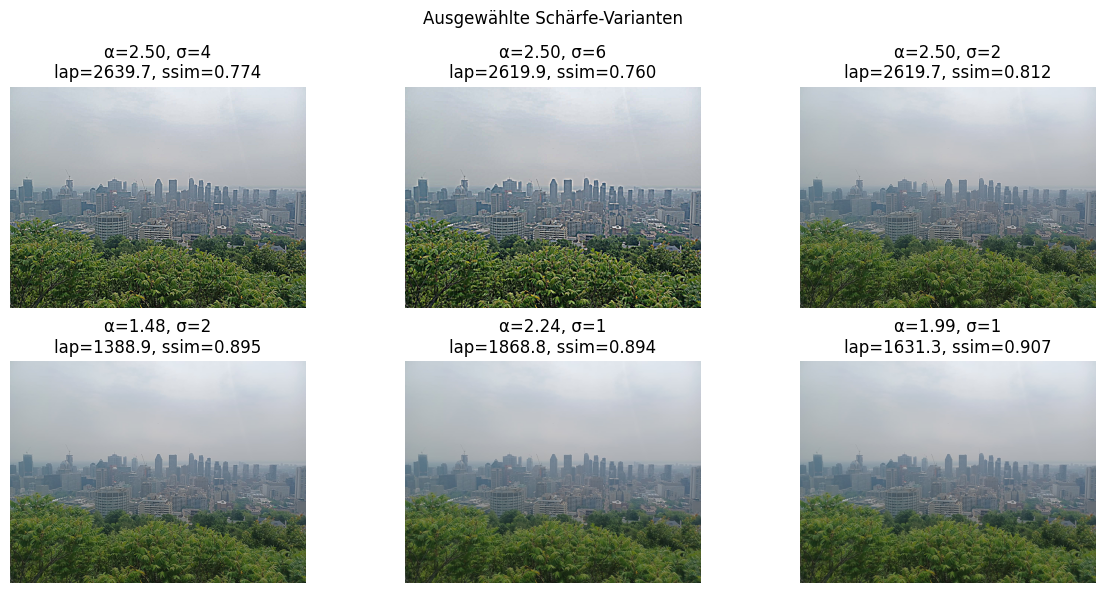

In [52]:
# Lade Bild (RGB für Anzeige/SSIM)
sky_bgr = cv2.imread('Images/skyline.jpg')
if sky_bgr is None:
    raise FileNotFoundError("Images/skyline.jpg nicht gefunden")
sky = cv2.cvtColor(sky_bgr, cv2.COLOR_BGR2RGB)

alphas = np.linspace(0.2, 2.5, 10)      # Schärfe-Faktoren
sigmas = [1, 2, 4, 6, 8]                # Gaussian blur sigma
results = []

for alpha in alphas:
    for sigma in sigmas:
        # Wähle Kernel aus (odd) abhängig von sigma
        k = int(max(3, 2*int(3*sigma)+1))
        blurred = cv2.GaussianBlur(sky, (k,k), sigmaX=sigma, sigmaY=sigma)
        sharpened = cv2.addWeighted(sky, 1+alpha, blurred, -alpha, 0)

        # Metriken
        ssim_val = ssim(sky, sharpened, channel_axis=-1)
        psnr_val = psnr(sky, sharpened, data_range=255)
        lap_var = cv2.Laplacian(cv2.cvtColor(sharpened, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var()
        results.append({'alpha': alpha, 'sigma': sigma, 'ssim': ssim_val, 'psnr': psnr_val, 'lap_var': lap_var, 'img': sharpened})

# Beispiel: Top-3 nach Laplacian (schärfste Varianten)
sorted_by_sharp = sorted(results, key=lambda x: -x['lap_var'])
for r in sorted_by_sharp[:3]:
    print(r['alpha'], r['sigma'], f"lap_var={r['lap_var']:.1f}, ssim={r['ssim']:.3f}, psnr={r['psnr']:.2f}")

# Visualisiere 6 Variationen (z.B. drei stärkste + drei ausgewogene)
sel = sorted_by_sharp[:3] + sorted(results, key=lambda x: abs(x['ssim']-0.9))[:3]
plt.figure(figsize=(12,6))
for i, r in enumerate(sel):
    plt.subplot(2,3,i+1); plt.imshow(r['img']); plt.axis('off')
    plt.title(f"α={r['alpha']:.2f}, σ={r['sigma']}\nlap={r['lap_var']:.1f}, ssim={r['ssim']:.3f}")
plt.suptitle("Ausgewählte Schärfe-Varianten")
plt.tight_layout(); plt.show()